In [111]:
# ML2 Final Project
# DS4420
# Christian Peterson, Shreesh Dassarkar, Jack Roberge
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pymc
import arviz as az
import pymc.sampling.jax as pymc_jax
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [79]:
nfl_data = pd.read_csv("/Users/Peterson/Documents/GitHub/DS4420-Final-Project/nfl_2019.csv")
print(len(nfl_data))

C:\Users\Peterson\AppData\Local\Temp\ipykernel_8200\3948928638.py:1: DtypeWarning: Columns (42,167,168,169,170,175,176,179,180,183,184,189,190,191,192,195,196,199,200,204,205,206,219,220,221,222,223,224,227,228,232,233,234,239,241,242) have mixed types. Specify dtype option on import or set low_memory=False.
  nfl_data = pd.read_csv("/Users/Peterson/Documents/GitHub/DS4420-Final-Project/nfl_2019.csv")


47548


(array([1.000e+00, 0.000e+00, 0.000e+00, 6.000e+00, 8.000e+00, 9.000e+00,
        1.100e+01, 1.800e+01, 2.600e+01, 4.900e+01, 1.070e+02, 1.550e+02,
        1.940e+02, 3.390e+02, 5.270e+02, 1.887e+03, 7.807e+03, 1.854e+04,
        7.246e+03, 4.474e+03, 2.121e+03, 1.126e+03, 4.900e+02, 1.680e+02,
        7.700e+01, 5.100e+01, 1.800e+01, 1.100e+01, 3.000e+00, 2.000e+00]),
 array([-13.49472   , -12.73673487, -11.97874973, -11.2207646 ,
        -10.46277947,  -9.70479433,  -8.9468092 ,  -8.18882407,
         -7.43083893,  -6.6728538 ,  -5.91486867,  -5.15688353,
         -4.3988984 ,  -3.64091327,  -2.88292813,  -2.124943  ,
         -1.36695787,  -0.60897273,   0.1490124 ,   0.90699753,
          1.66498267,   2.4229678 ,   3.18095293,   3.93893807,
          4.6969232 ,   5.45490833,   6.21289347,   6.9708786 ,
          7.72886373,   8.48684887,   9.244834  ]),
 <BarContainer object of 30 artists>)

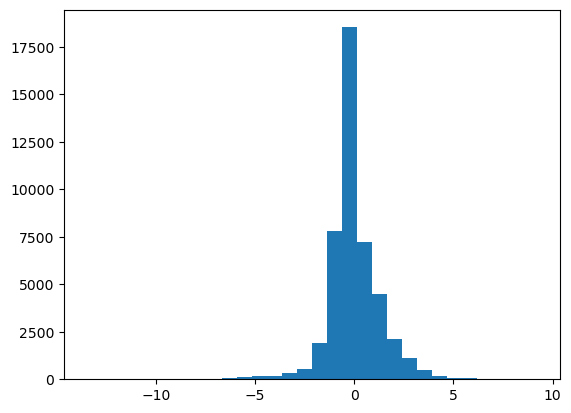

In [80]:
plt.hist(nfl_data["epa"], bins=30)

In [81]:
bool_df = nfl_data[["epa", "yardline_100", "down", "ydstogo", 
                    "quarter_seconds_remaining", "play_type"]]
# Find where data is missing in all of these
# We won't be able to classify these

# Remove where EPA is missing
nan = bool_df.loc[bool_df["epa"].isna()]
bool_df = bool_df.drop(index=nan.index)

# NaNs are insignificant reduction in DF size, so remove those rows
cols = ["epa", "yardline_100", "down", "ydstogo", 
                    "quarter_seconds_remaining", "play_type"]
for col in cols:
    nan = bool_df.loc[bool_df[col].isna()]
    print(f"{col}: {len(nan)}")
    bool_df = bool_df.drop(index=nan.index)

print(len(bool_df))

epa: 0
yardline_100: 60
down: 5876
ydstogo: 0
quarter_seconds_remaining: 0
play_type: 0
39535


In [82]:
print(bool_df.iloc[0])

epa                          0.86296
yardline_100                    75.0
down                             1.0
ydstogo                           10
quarter_seconds_remaining      900.0
play_type                       pass
Name: 198, dtype: object


In [83]:
print(set(bool_df["play_type"]))  
# note - we no longer have data for Kickoff & Extra point 
# (these are fine, i think extra point would skew the model)

{'run', 'punt', 'qb_kneel', 'qb_spike', 'no_play', 'pass', 'field_goal'}


In [84]:
# Data cleaning / manipulation functions

def encode_x(x_df, categ_ttls):
    """
    Encode all the categorical features
    using the categorical column names by
    updating the DataFrame
    """
    for col in categ_ttls:
        categ_data = x_df[col].values.reshape(-1, 1)

        # Encode
        encoder = OneHotEncoder()
        categ_encoded = encoder.fit_transform(categ_data)

        # Handle multidimensional bools
        encoded_full = pd.DataFrame(
            categ_encoded.toarray(),
            columns=encoder.get_feature_names_out([col]),
            #index=x_df[col].index
            index=x_df.index
        )

        # Add to the df
        x_df = x_df.drop(columns=[col])
        x_df = pd.concat([x_df, encoded_full], axis=1)

    return x_df

def scale_df(df, min_max, std):
    """
    Scale a DataFrame's features by
    differentiating between columns that require
    min-max scaling and standardization
    """
    # Min-max columns
    minmax_scaler = MinMaxScaler()
    df[min_max] = minmax_scaler.fit_transform(df[min_max])        

    # Standardized columns
    std_scaler = StandardScaler()
    df[std] = std_scaler.fit_transform(df[std])

    return df

In [85]:
# Encode the play_type categorical variable
bool_df = encode_x(bool_df, ["down", "play_type"])
print(bool_df.iloc[0])

# Scale the data
minmax_cols = ["yardline_100", "ydstogo", "quarter_seconds_remaining"]
std_cols = ["epa"]
bool_df = scale_df(bool_df, minmax_cols, std_cols)
print("\n",bool_df.iloc[0])

epa                            0.86296
yardline_100                  75.00000
ydstogo                       10.00000
quarter_seconds_remaining    900.00000
down_1.0                       1.00000
down_2.0                       0.00000
down_3.0                       0.00000
down_4.0                       0.00000
play_type_field_goal           0.00000
play_type_no_play              0.00000
play_type_pass                 1.00000
play_type_punt                 0.00000
play_type_qb_kneel             0.00000
play_type_qb_spike             0.00000
play_type_run                  0.00000
Name: 198, dtype: float64

 epa                          0.602235
yardline_100                 0.755102
ydstogo                      0.230769
quarter_seconds_remaining    1.000000
down_1.0                     1.000000
down_2.0                     0.000000
down_3.0                     0.000000
down_4.0                     0.000000
play_type_field_goal         0.000000
play_type_no_play            0.000000
play_ty

In [105]:
# Split the data into training and test sets
x_data = bool_df.drop(columns=["epa"])
y_data = bool_df["epa"]

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data,
                                                   test_size=0.2, random_state=42)

In [87]:
# Create the model
df_down = x_train.iloc[:, [3, 4, 5, 6]]
df_playtype = x_train.iloc[:, [7, 8, 9, 10, 11, 12, 13]]

with pymc.Model() as epa_norm:
    # Weight Priors
    w0 = pymc.Normal("w0", mu=0, sigma=1)
    w_yardline = pymc.Normal("w_yardline", mu=1.5, sigma=1)
    w_ydstogo = pymc.Normal("w_ydstogo", mu=1.5, sigma=1)
    w_qtrsecs = pymc.Normal("w_qtrsecs", mu=1, sigma=0.5)
    w_down = pymc.Normal("w_down", mu=-1, sigma=0.5, shape=df_down.shape[1])
    w_playtype = pymc.Normal("w_playtype", mu=0, sigma=1, shape=df_playtype.shape[1])

    # Calculate Mu
    mu = (
        w0 +
        w_yardline * x_train["yardline_100"] +
        w_ydstogo * x_train["ydstogo"] +
        w_qtrsecs * x_train["quarter_seconds_remaining"] +
        w_down @ df_down.T +
        w_playtype @ df_playtype.T 
    )

    # Create the Likelihood
    # Define sigma first
    sigma = pymc.InverseGamma("sigma", alpha=1.5, beta=1)
    epa_data = pymc.Normal("epa_data", mu=mu, sigma=sigma,
                           observed=y_train)  # likelihood

    # Obtain samples from posterior
    post_samples = pymc_jax.sample_numpyro_nuts(
                               draws=1000, 
                               tune=180,  # burn
                               chains=4,  # need these 4 to converge
                               target_accept=0.95,
                               #return_inferencedata=True
    )

  0%|          | 0/1180 [00:00<?, ?it/s]

  0%|          | 0/1180 [00:00<?, ?it/s]

  0%|          | 0/1180 [00:00<?, ?it/s]

  0%|          | 0/1180 [00:00<?, ?it/s]

In [89]:
# Obtain summary output to interpret coefficients
print(az.summary(post_samples, round_to=2))

               mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
w0             0.79  0.41    0.04     1.57       0.01     0.01   1101.24   
w_yardline     0.07  0.02    0.02     0.12       0.00     0.00   3734.73   
w_ydstogo     -0.36  0.06   -0.46    -0.26       0.00     0.00   3016.45   
w_qtrsecs      0.05  0.02    0.02     0.09       0.00     0.00   3534.86   
w_down[0]     -0.94  0.24   -1.36    -0.49       0.01     0.00    952.31   
w_down[1]     -0.94  0.24   -1.36    -0.49       0.01     0.00    953.63   
w_down[2]     -0.97  0.24   -1.39    -0.52       0.01     0.00    962.69   
w_down[3]     -0.97  0.24   -1.40    -0.52       0.01     0.00    927.10   
w_playtype[0]  0.14  0.36   -0.54     0.79       0.01     0.01   1289.71   
w_playtype[1]  0.12  0.36   -0.57     0.75       0.01     0.01   1275.77   
w_playtype[2]  0.19  0.36   -0.48     0.84       0.01     0.01   1273.14   
w_playtype[3]  0.29  0.36   -0.39     0.93       0.01     0.01   1283.42   
w_playtype[4

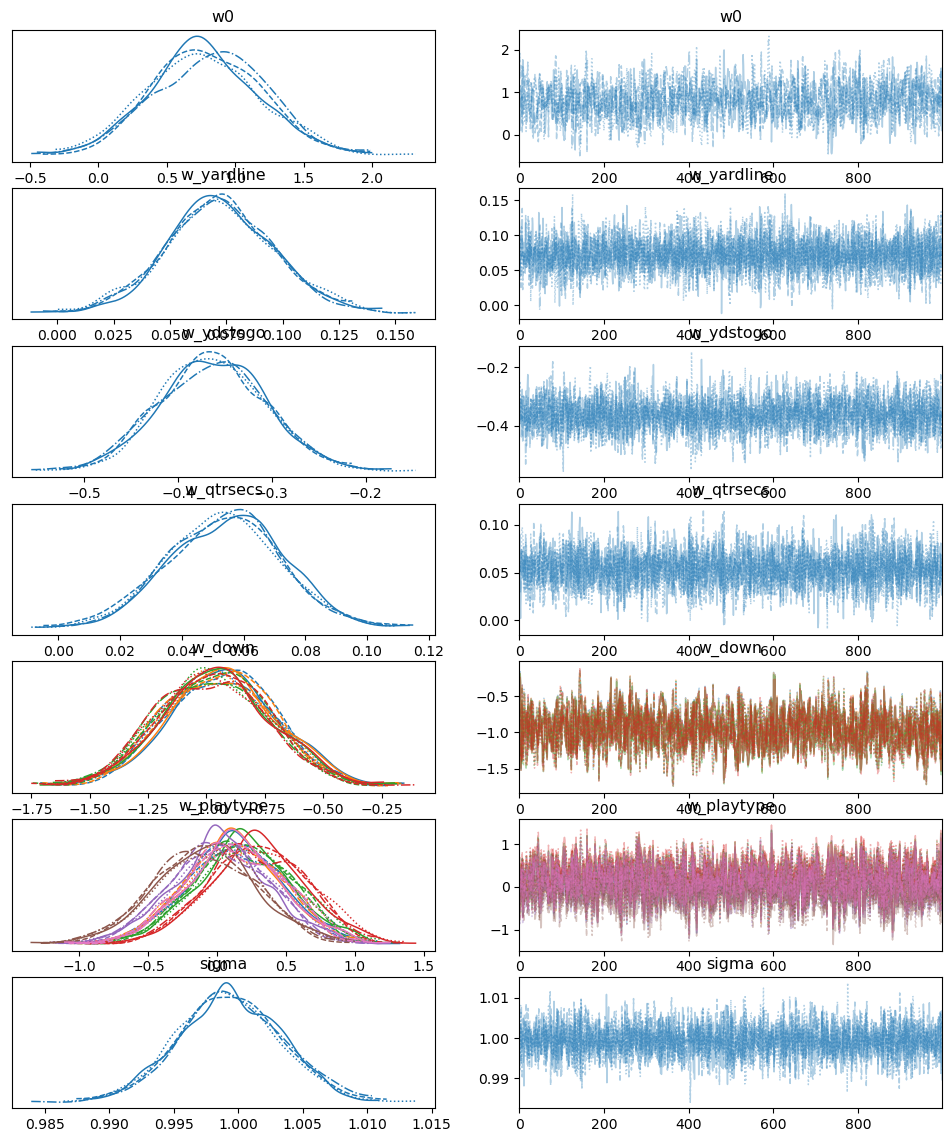

In [90]:
# Obtain plots to assess distributions & chain convergence
az.plot_trace(post_samples)
plt.show()

Sampling: [epa_data]


Output()

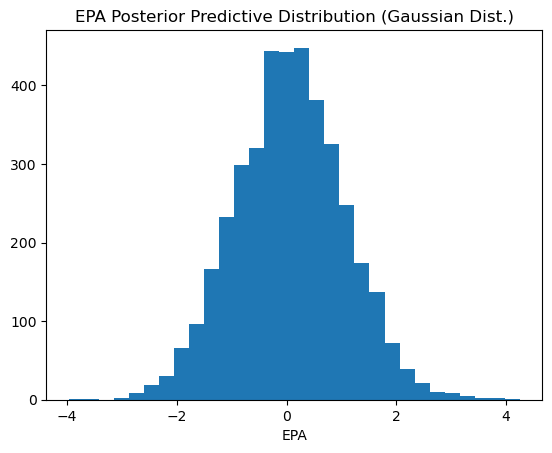

In [73]:
# Visualize the Posterior Predictive samples
with epa_norm:
    preds_norm = pymc.sample_posterior_predictive(post_samples, var_names=["epa_data"])

# Plot the histogram
plt.hist(preds_norm.posterior_predictive["epa_data"][:, :, 0].values.ravel(), bins=30)
plt.title("EPA Posterior Predictive Distribution (Gaussian Dist.)")
plt.xlabel("EPA")
plt.show()

In [106]:
# Find the dimensions to reshape categorical variables by
n_samples = post_samples.posterior["w0"].values.size  # chains * draws

# Reshape all parameters for predictions
w0_flat = post_samples.posterior["w0"].values.flatten()
w_yardline_flat = post_samples.posterior["w_yardline"].values.flatten()
w_ydstogo_flat = post_samples.posterior["w_ydstogo"].values.flatten()
w_qtrsecs_flat = post_samples.posterior["w_qtrsecs"].values.flatten()
w_down_flat = post_samples.posterior["w_down"].values.reshape(n_samples, -1)
w_playtype_flat = post_samples.posterior["w_playtype"].values.reshape(n_samples, -1)

# Calculate predictions for posterior samples
mu_test_all = (
    w0_flat[:, None] +
    w_yardline_flat[:, None] * x_test["yardline_100"].values +
    w_ydstogo_flat[:, None] * x_test["ydstogo"].values +
    w_qtrsecs_flat[:, None] * x_test["quarter_seconds_remaining"].values +
    w_down_flat @ df_down_test.values.T +
    w_playtype_flat @ df_playtype_test.values.T
)

# Obtain the predictions to compare with the actual (it is a distribution, so average it)
# Average across all posterior samples
y_pred = mu_test_all.mean(axis=0)

# Check to make sure shape is equivalent
y_pred_lower = np.percentile(mu_test_all, 2.5, axis=0)
y_pred_upper = np.percentile(mu_test_all, 97.5, axis=0)

print(f"Predictions shape: {y_pred.shape}")
print(f"Expected shape: {y_test.shape}")

Predictions shape: (7907,)
Expected shape: (7907,)


In [110]:
# EPA
print(y_pred)
print(y_test.values)

[ 0.14844189 -0.04169955  0.05772657 ...  0.02092155 -0.00371812
  0.03966352]
[-0.57145184 -0.37648566 -0.90581503 ... -1.11657079 -0.4524574
  0.86360883]



Test Set Performance:
  R²: 0.0018
  RMSE: 0.9954
  MAE: 0.6919


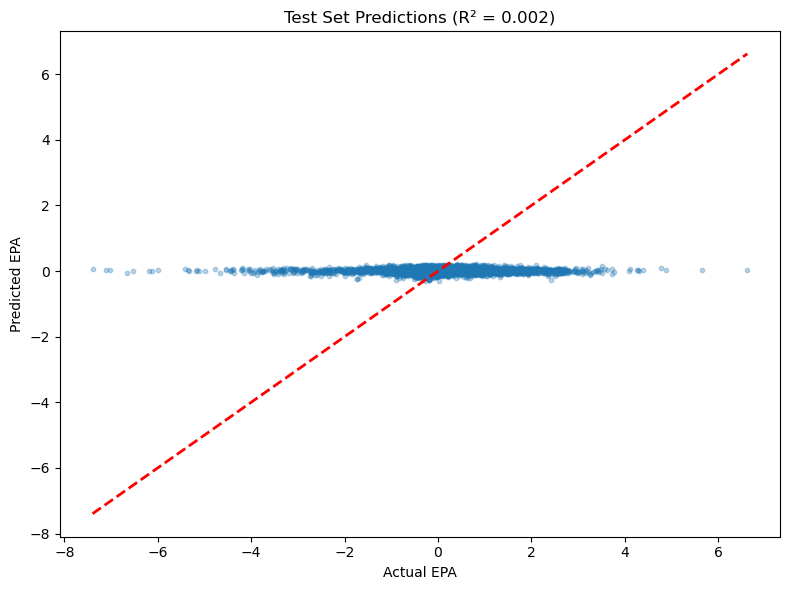

In [107]:
# NEW - Assess Cross Validation data
# Calculate metrics
test_r2 = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)

print(f"\nTest Set Performance:")
print(f"  R²: {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE: {test_mae:.4f}")

# Plot predictions vs actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual EPA")
plt.ylabel("Predicted EPA")
plt.title(f"Test Set Predictions (R² = {test_r2:.3f})")
plt.tight_layout()
plt.show()